In [1]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    message: str

def greeting_node(state: AgentState)-> AgentState:
    """Simple node that adds a greeting message"""
    state['message'] = f"{state['message']}, you are doing a great job learning LangGraph"
    return state

graph = StateGraph(AgentState)

graph.add_node("greeter",greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()

result = app.invoke({'message':"Bob"})
result['message']

'Bob, you are doing a great job learning LangGraph'

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
import math

class AgentState(TypedDict):
    name: str
    values: List[int]
    operation: str
    result: str

def process(state: AgentState)-> AgentState:
    """ Function to add or multiply the set of given values """

    if state['operation'] == "+":
        state["result"] = f"hey there {state['name']} your sum is {sum(state['values'])}"
    elif state['operation'] == "*":
        state["result"] = f"hey there {state['name']} your product is {math.prod(state['values'])}"

    return state

graph = StateGraph(AgentState)

graph.add_node("processor", process)
graph.set_entry_node("processor")
graph.set_finish_node("processor")

app = graph.compile()

ans = app.invoke({"name": "Jack Sparrow", "values": [1,2,3,4,5], "operation": "*"})

In [ ]:
# 3 assignment

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    result: str

def first_node(state: AgentState)->AgentState:
    """ First node of the graph which prints the name and greeting. """

    state["result"] = f"Hi {state['name']}. Welcome to the team !!!"

    return state

def second_node(state: AgentState)-> AgentState:
    """ Second node of the graph which prints the age  """

    state["result"] = state["result"] + f"You are {state['age']} years old."

    return state

def third_node(state: AgentState)-> AgentState:
    """ Third node of the graph which prints the skills """

    state["result"] = state["result"] + f"You have skills in : {', '.join(state['skills'])}"

    return state

graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.add_node("third_node", third_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.add_edge("second_node", "third_node")
graph.set_finish_point("third_node")

app = graph.compile()

final = app.invoke({"name": "Kishna", "age": 26, "skills" : ["Machine Learning", "Java SpringBoot", "Generative AI"]})
print(final["result"])

Hi Kishna. Welcome to the team !!!You are 26 years old.You have skills in : Machine Learning, Java SpringBoot, Generative AI


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
    num1 : int
    num2 : int
    op1 : str
    num3 : int
    num4 : int
    op2 : str
    ans1 : int 
    ans2 : int

def add_node1(state: AgentState)-> AgentState:
    """ First addtion node to add to perform the addition op"""
    state["ans1"] = state["num1"] + state["num2"]
    return state

def sub_node1(state: AgentState)-> AgentState:
    """ Node to perform 1st subtrtaction operation """
    state["ans1"] = state["num1"] - state["num2"]
    return state

def add_node2(state: AgentState)-> AgentState:
    """ node to perform the 2nd addition op"""
    state["ans2"] = state["num3"] + state["num4"]
    return state

def sub_node2(state: AgentState)-> AgentState:
    """ Node to perform 2nd subtrtaction operation """
    state["ans2"] = state["num3"] - state["num4"]
    return state

def decide_next_node1(state: AgentState)-> AgentState:
    """ Node which will decide in which direction to proceed """
    if state["op1"] == "+":
        return "addition_op1"
    if state["op1"] == "-":
        return "subtract_op1"

def decide_next_node2(state: AgentState)-> AgentState:
    """ Node which will decide in which direction to proceed """
    if state["op2"] == "+":
        return "addition_op2"
    if state["op2"] == "-":
        return "subtract_op2"

graph = StateGraph(AgentState)
graph.add_node("add_node1", add_node1)
graph.add_node("sub_node1", sub_node1)
graph.add_node("add_node2", add_node2)
graph.add_node("sub_node2", sub_node2)
graph.add_node("router1", lambda state:state)
graph.add_node("router2", lambda state:state)

graph.add_edge(START, "router1")
graph.add_conditional_edges("router1",
                           decide_next_node1,
                           {
                               "addition_op1": "add_node1",
                               "subtract_op1": "sub_node1"
                           })
graph.add_edge("add_node1", "router2")
graph.add_edge("sub_node1", "router2")
graph.add_conditional_edges("router2",
                           decide_next_node2,
                           {
                               "addition_op2": "add_node2",
                               "subtract_op2": "sub_node2"
                           })
graph.add_edge("add_node2", END)
graph.add_edge("sub_node2", END)

app = graph.compile()
result = app.invoke({"num1" : 25, "num2": 21, "num3" : 56, "num4":51, "op1" : "+", "op2":"-"})
print(result["ans1"]) 
print(result["ans2"])

46
5


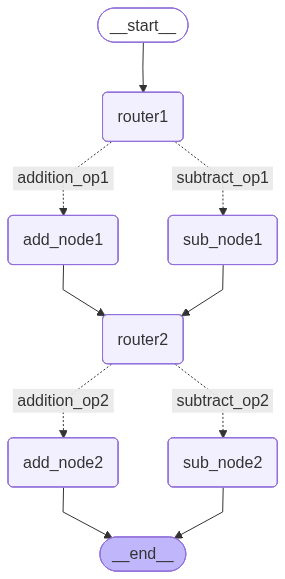

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph,START, END
import random

class AgentState(TypedDict):
    player_name : str
    attempts : int
    guess : int
    guesses : List[int]
    num : int
    lower_limit : int
    higher_limit : int

def setup(state : AgentState)-> AgentState:
    """ A setup node to greet the player and set the no of gusses """
    state["player_name"] = f"Hi there {state['player_name']}, lets start the game"
    state["attempts"] = 15
    return state

def guess_the_number(state: AgentState) -> AgentState:
    state["guess"] = random.randint(state["lower_limit"],state["higher_limit"])
    state["guesses"].append(state["guess"])
    state["attempts"] -= 1

    return state

def should_continue(state: AgentState) -> AgentState:
    if(state["attempts"]==0):
        print("Oooo! You Missed. Try again next time.")
        return "exit"

    elif(state["num"] == state["guess"] ):
        print("Congragulations you guessed the number right")
        return "exit"
    
    elif(state["num"] < state["guess"]):
        state["higher_limit"] = state["guess"]
        return "loop"
        
    elif(state["num"] > state["guess"]):
        state["lower_limit"] = state["guess"]
        return "loop"
    
graph = StateGraph(AgentState)    
graph.add_node("setup", setup)   
graph.add_node("guess_number", guess_the_number)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess_number")

graph.add_conditional_edges("guess_number",
                           should_continue,{
                               "loop" : "guess_number",
                               "exit" : END
                           })
app = graph.compile()

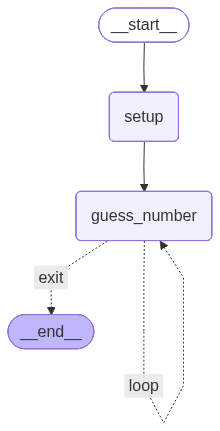

In [ ]:
# Visual representation of the graph 
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
result = app.invoke({"player_name":"Animesh Gawhale", "attempts" : 25, "num" : 58, "lower_limit":1, "higher_limit": 100, "guesses":[]})
print(result)

Congragulations you guessed the number right
{'player_name': 'Hi there Animesh Gawhale, lets start the game', 'attempts': 3, 'guess': 58, 'guesses': [54, 22, 76, 85, 99, 76, 82, 62, 79, 99, 64, 58], 'num': 58, 'lower_limit': 1, 'higher_limit': 100}
